In [1]:
import utils
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

2026-02-22 20:20:09.299059: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-22 20:20:09.800555: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 20:20:21.352249: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
other = 'Other car'

In [39]:
columns = ("model", "lighting")
(train_x, train_y), (test_x, test_y) = utils.read_stratified_data(columns=columns, strata_threshold=38)

/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/kisspng-2018-tesla-model-s-tesla-motors-car-ele_fLj30kA.2230115115224762368998.png
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/Edmu_EmY1CYe.-2020-Tesla-Model-Ywire-38540856-1611748943-973_634x3962-1280x720.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/275815406_Andrew-Crowley-1_trans_NvBQzQNjv4BqJgZjG4XE8BZGTSy9SLp5TPzOL_bEerq8T.jpg
/mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett/black-tesla-model-x-carbon-fiber-spoiler-mx22-forged-aftermarket-wheel_tCrLNla.jpg


In [40]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(3695, 300, 300, 3)
(3695, 5)
(640, 300, 300, 3)
(640, 5)


In [41]:
columns = ["model", "lighting"]


strata_train = train_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

strata_test = test_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

comparison = pd.DataFrame({
    'treningssett': strata_train,
    'testsett': strata_test
})

comparison = comparison.fillna(0).astype(int)

comparison['train_%'] = (comparison['treningssett'] / comparison['treningssett'].sum() * 100).round(2)
comparison['test_%'] = (comparison['testsett'] / comparison['testsett'].sum() * 100).round(2)

comparison = comparison.sort_values(by='testsett')

print(comparison)

                    treningssett  testsett  train_%  test_%
S 2016–nå-Dark                15         0     0.41    0.00
S 2016–nå-Medium              17         0     0.46    0.00
S 2012–2015-Medium            11         0     0.30    0.00
S 2012–2015-Dark               9         0     0.24    0.00
X-Medium                      25         0     0.68    0.00
X-Dark                        37         6     1.00    0.94
Y 2025-nå-Light               56        10     1.52    1.56
3 2024–nå-Dark                67        12     1.81    1.88
3 2024–nå-Medium              66        12     1.79    1.88
Other car-Medium              71        13     1.92    2.03
S 2012–2015-Light             75        13     2.03    2.03
3 2024–nå-Light               76        13     2.06    2.03
Other car-Dark                81        14     2.19    2.19
S 2016–nå-Light               87        15     2.35    2.34
3 2017–2023-Medium            84        15     2.27    2.34
3 2017–2023-Dark              88        

In [ ]:
columns = ["model"]

train_key = train_y[list(columns)].fillna('').astype(str).agg('-'.join, axis=1)
test_key = test_y[list(columns)].fillna('').astype(str).agg('-'.join, axis=1)

train_lighting = pd.crosstab(train_key, train_y['lighting'])
test_lighting = pd.crosstab(test_key, test_y['lighting'])

desired_order = ['Light', 'Medium', 'Dark']

all_indices = sorted(set(train_lighting.index) | set(test_lighting.index))
comparison = pd.DataFrame(index=all_indices)

for light in desired_order:
    tr_val = train_lighting[light] if light in train_lighting.columns else pd.Series(0, index=comparison.index)
    te_val = test_lighting[light] if light in test_lighting.columns else pd.Series(0, index=comparison.index)

    tr = tr_val.reindex(comparison.index, fill_value=0)
    te = te_val.reindex(comparison.index, fill_value=0)
    
    comparison[light] = tr.astype(str) + "/" + te.astype(str)

print(comparison)

                Light  Medium    Dark
3 2017–2023    121/21   84/15   88/15
3 2024–nå       76/13   66/12   67/12
Other car    1593/282   71/13   81/14
S 2012–2015     75/13    11/0     9/0
S 2016–nå       87/15    17/0    15/0
X              169/30    25/0    37/6
Y 2020–2024    330/59  198/35  199/35
Y 2025-nå       56/10  116/21  104/19


In [ ]:
i = 0

color       Black/Dark gray
lighting              Light
model             Other car
year                    NaN
source             external
Name: 492, dtype: object


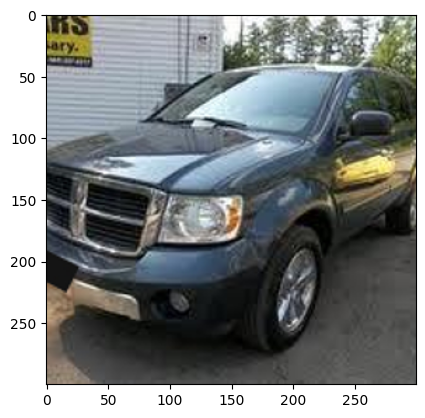

In [32]:
print(train_y.iloc[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [8]:
train_y_new = train_y["model"]

def t(x):
    if x == 'Other car':
        return 1
    return 0

vt = np.vectorize(t)

train_y_new = vt(train_y_new)

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y_new,
    epochs=epochs,
)

I0000 00:00:1771772930.747396   24818 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5


2026-02-22 16:08:57.510311: I external/local_xla/xla/service/service.cc:163] XLA service 0x7af620005620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-22 16:08:57.510436: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-22 16:08:57.644781: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-22 16:08:57.956471: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


  3/116 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4913 - loss: 0.8315 

I0000 00:00:1771772944.087780   25170 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.7051 - loss: 0.5699
Epoch 2/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8152 - loss: 0.4277
Epoch 3/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8609 - loss: 0.3375
Epoch 4/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8996 - loss: 0.2629
Epoch 5/5
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9394 - loss: 0.1837


In [9]:
test_y_new = test_y["model"]
test_y_new = vt(test_y_new)

functional_model.evaluate(test_x, test_y_new)

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8268 - loss: 0.4475

2026-02-22 16:09:31.894131: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 4 bytes spill stores, 4 bytes spill loads

2026-02-22 16:09:31.905146: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 4 bytes spill stores, 4 bytes spill loads



20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.8091 - loss: 0.4414


[0.4413639307022095, 0.8090766668319702]

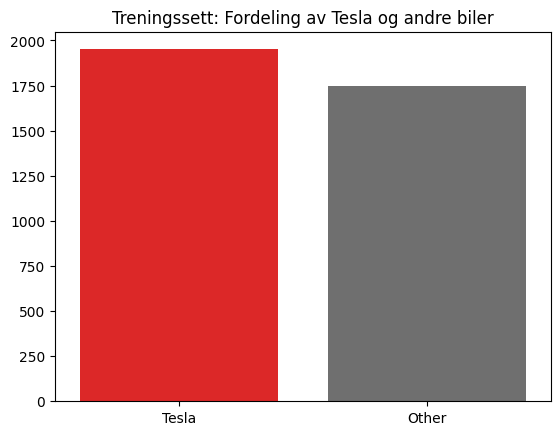

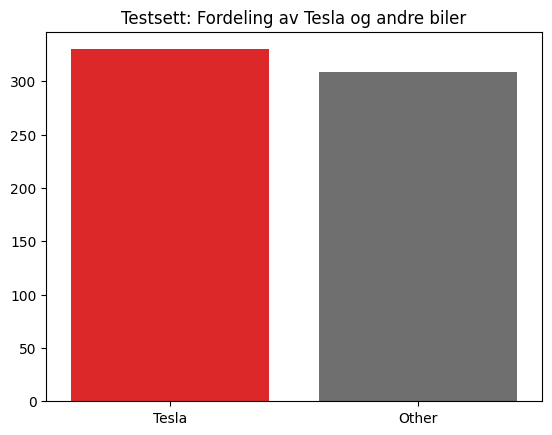

In [10]:
df = train_y
other = 'Other car'

names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
plt.show()

df = test_y
names = ['Tesla', 'Other']
counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
plot.set_title(f'Testsett: Fordeling av Tesla og andre biler')
plt.show()

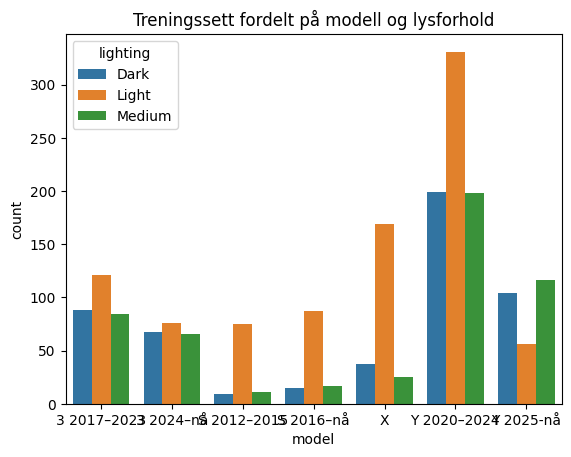

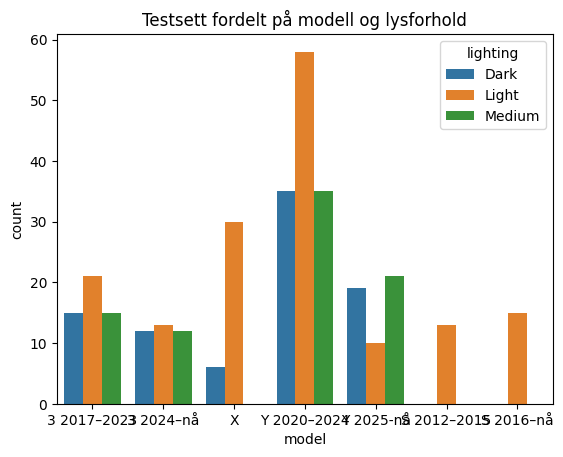

: 

In [ ]:
df = train_y
other = 'Other car'
tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting", kind='stable')

sns.countplot(data=tesla, x="model", hue="lighting").set_title("Treningssett fordelt på modell og lysforhold")
plt.show()

df = test_y
tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting", kind='stable')

sns.countplot(data=tesla, x="model", hue="lighting").set_title("Testsett fordelt på modell og lysforhold")
plt.show()

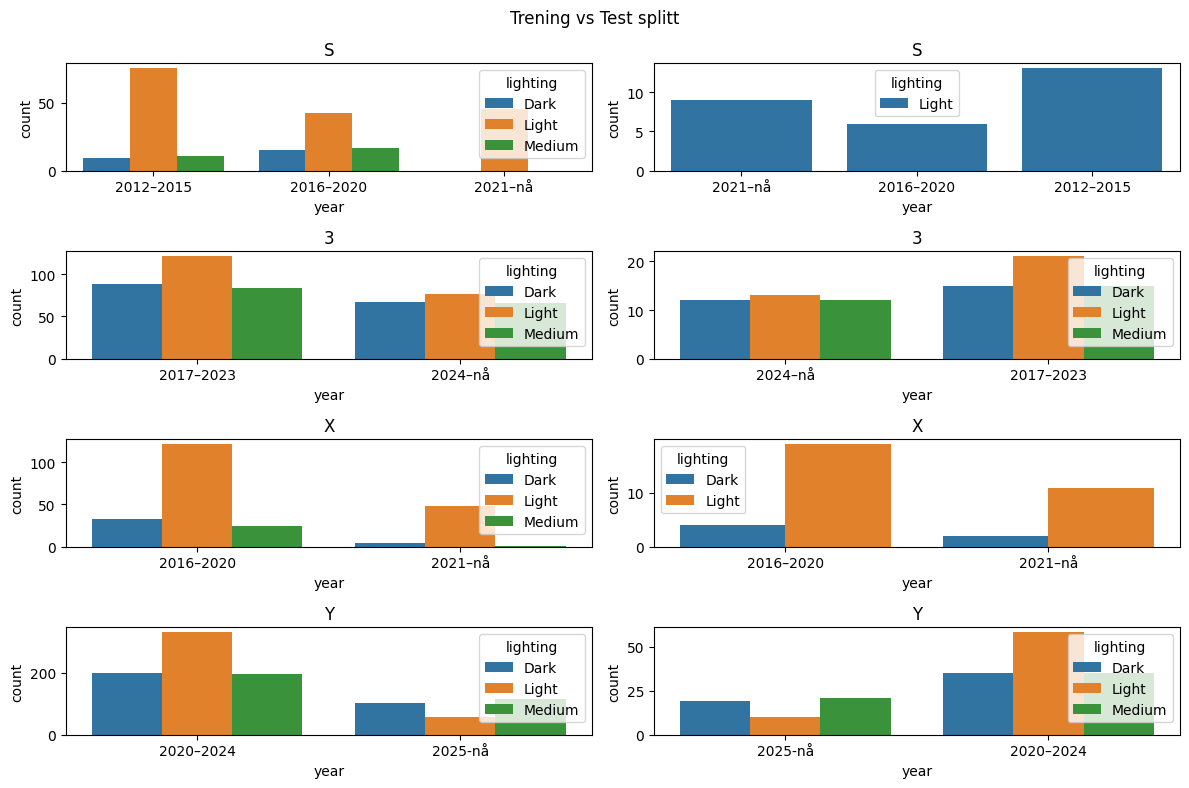

In [12]:
train_y_split = [
    train_y[train_y['model'].str.contains('S')].sort_values('lighting').sort_values('year', kind='stable'),
    train_y[train_y['model'].str.contains('3')].sort_values('lighting').sort_values('year', kind='stable'),
    train_y[train_y['model'].str.contains('X')].sort_values('lighting').sort_values('year', kind='stable'),
    train_y[train_y['model'].str.contains('Y')].sort_values('lighting').sort_values('year', kind='stable')
]
test_y_split = [
    test_y[test_y['model'].str.contains('S')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('3')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('X')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('Y')].sort_values('lighting').sort_values('lighting', kind='stable')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='year', data=train_y_split[i*2 + j], ax=axes[i*2+j,0], hue='lighting')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='year', data=test_y_split[i*2 + j], ax=axes[i*2+j,1], hue='lighting')
        axes[i*2+j,1].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

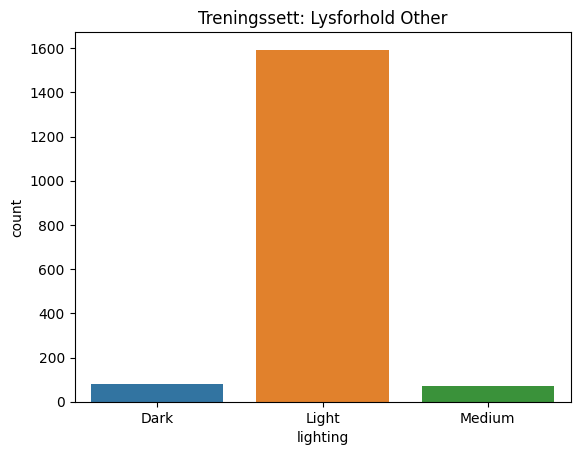

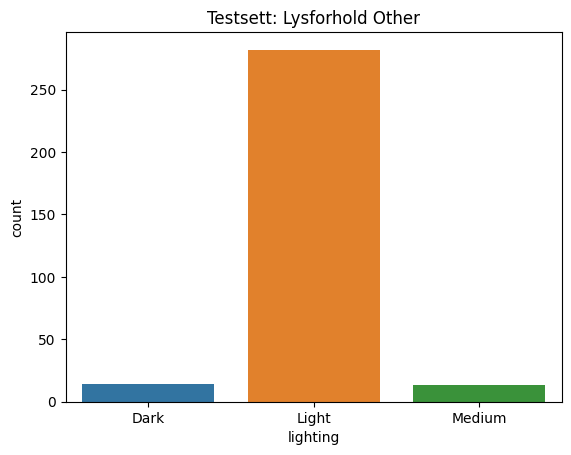

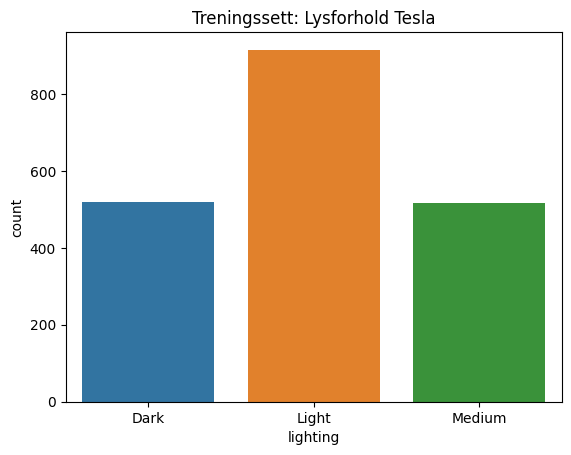

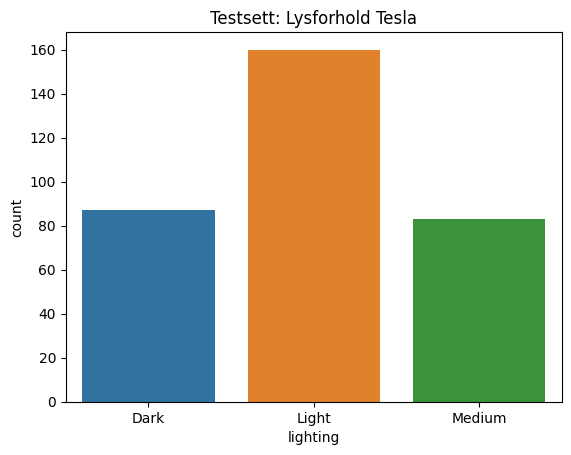

In [13]:
df = train_y[train_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Other')
plt.show()

df = test_y[test_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Other')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Tesla')
plt.show()